In [1]:
# Run this first in Colab — installs the only library not pre-installed
!pip install wordcloud --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Make all charts look clean
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


In [3]:
# -------------------------------------------------------
# WHY: We don't have real data, so we generate realistic
#       synthetic poll data to simulate a survey about
#       "Preferred Data Science Tools Among Students"
# -------------------------------------------------------

np.random.seed(42)
n = 300  # 300 survey respondents

# --- Define possible values ---
age_groups    = ['18-24', '25-34', '35-44', '45+']
genders       = ['Male', 'Female', 'Non-binary']
regions       = ['North', 'South', 'East', 'West']
tools         = ['Python', 'R', 'Excel', 'SQL', 'Tableau']
edu_levels    = ['Undergraduate', 'Postgraduate', 'Working Professional']

# --- Define weighted distributions to make data realistic ---
age_weights    = [0.50, 0.30, 0.12, 0.08]
gender_weights = [0.52, 0.42, 0.06]
region_weights = [0.25, 0.25, 0.25, 0.25]
tool_weights   = [0.40, 0.15, 0.20, 0.15, 0.10]
edu_weights    = [0.50, 0.30, 0.20]

# --- Feedback templates to simulate open-ended responses ---
feedback_pool = [
    "Python is very powerful and easy to learn.",
    "I prefer Excel because it is beginner friendly.",
    "R is great for statistics and research.",
    "SQL is essential for database-related work.",
    "Tableau makes visualizations very easy.",
    "Python has a huge community and many libraries.",
    "Excel dashboards are quick to build.",
    "R is excellent for data science research.",
    "Python automation saves a lot of time.",
    "SQL is must-know for any data analyst.",
    "Tableau is visually appealing and interactive.",
    "I find Python very useful for machine learning.",
    "Excel is not great for large datasets.",
    "R syntax can be confusing for beginners.",
    "Python is the best language for beginners.",
]

# --- Generate timestamps over 30 days ---
dates = pd.date_range(start='2024-03-01', periods=30, freq='D')
timestamps = np.random.choice(dates, size=n)

# --- Build the DataFrame ---
df = pd.DataFrame({
    'Respondent_ID'  : [f'R{str(i+1).zfill(4)}' for i in range(n)],
    'Timestamp'      : timestamps,
    'Age_Group'      : np.random.choice(age_groups,  n, p=age_weights),
    'Gender'         : np.random.choice(genders,     n, p=gender_weights),
    'Region'         : np.random.choice(regions,     n, p=region_weights),
    'Education'      : np.random.choice(edu_levels,  n, p=edu_weights),
    'Preferred_Tool' : np.random.choice(tools,       n, p=tool_weights),
    'Satisfaction'   : np.random.choice([1,2,3,4,5], n, p=[0.05,0.10,0.20,0.35,0.30]),
    'Feedback'       : np.random.choice(feedback_pool, n),
})

# --- Introduce some realistic missing values (2%) ---
for col in ['Feedback', 'Satisfaction']:
    mask = np.random.choice([True, False], size=n, p=[0.02, 0.98])
    df.loc[mask, col] = np.nan

print(f"✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n🔍 First 5 rows:")
df.head()

✅ Dataset created: 300 rows × 9 columns

🔍 First 5 rows:


,Respondent_ID,Timestamp,Age_Group,Gender,Region,Education,Preferred_Tool,Satisfaction,Feedback
0,R0001,2024-03-07,25-34,Male,West,Postgraduate,Excel,4.0,Python is the best language for beginners.
1,R0002,2024-03-20,18-24,Male,North,Working Professional,Tableau,4.0,Tableau is visually appealing and interactive.
2,R0003,2024-03-29,25-34,Female,South,Working Professional,Python,4.0,Python is the best language for beginners.
3,R0004,2024-03-15,25-34,Female,North,Postgraduate,Excel,5.0,Python has a huge community and many libraries.
4,R0005,2024-03-11,25-34,Female,East,Undergraduate,Excel,4.0,Python is the best language for beginners.


In [4]:
# Save cleaned dataset so you can download it as proof
df.to_csv('cleaned_poll_data.csv', index=False)
print("✅ Cleaned data saved as 'cleaned_poll_data.csv'")
print("   (Go to the Files panel on the left → right-click → Download)")

✅ Cleaned data saved as 'cleaned_poll_data.csv'
   (Go to the Files panel on the left → right-click → Download)


In [5]:
# -------------------------------------------------------
# WHY: The first thing any analyst produces is a summary
#       table showing counts and percentages.
# -------------------------------------------------------

print("=" * 50)
print("       POLL RESULTS SUMMARY — PREFERRED TOOL")
print("=" * 50)

summary = (df['Preferred_Tool']
           .value_counts()
           .reset_index()
           .rename(columns={'Preferred_Tool': 'Tool', 'count': 'Votes'}))

summary['Vote_Share_%'] = (summary['Votes'] / summary['Votes'].sum() * 100).round(2)
summary['Rank']         = range(1, len(summary) + 1)
summary = summary[['Rank', 'Tool', 'Votes', 'Vote_Share_%']]

print(summary.to_string(index=False))
print(f"\n🏆 Winner: {summary.iloc[0]['Tool']} with {summary.iloc[0]['Vote_Share_%']}% of votes")
print(f"📊 Total Responses: {summary['Votes'].sum()}")
print(f"⭐ Average Satisfaction: {df['Satisfaction'].mean():.2f} / 5")

       POLL RESULTS SUMMARY — PREFERRED TOOL
 Rank    Tool  Votes  Vote_Share_%
    1  Python    119         39.67
    2   Excel     69         23.00
    3       R     44         14.67
    4     SQL     39         13.00
    5 Tableau     29          9.67

🏆 Winner: Python with 39.67% of votes
📊 Total Responses: 300
⭐ Average Satisfaction: 3.76 / 5


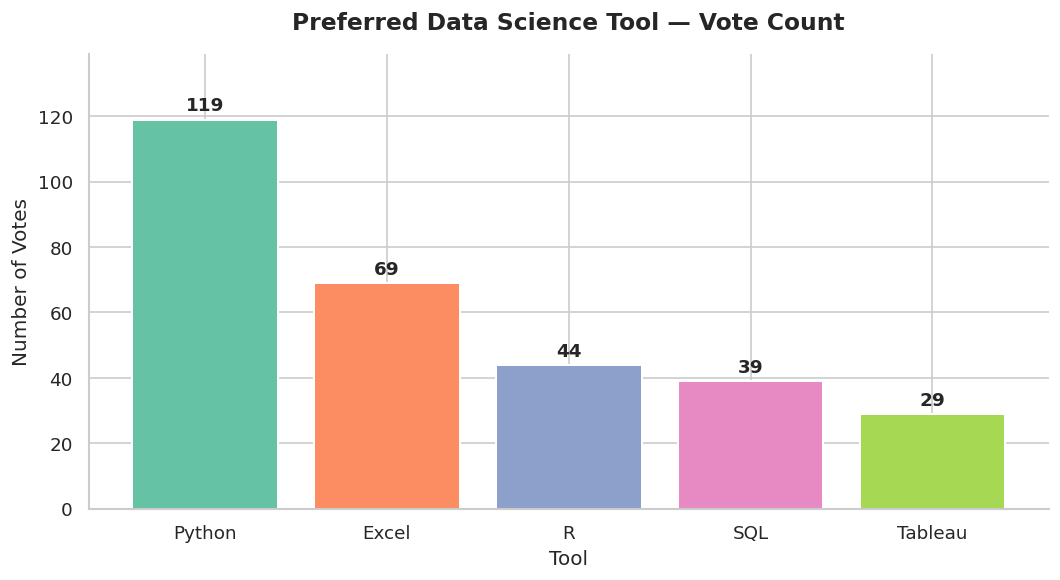

✅ Saved: chart1_bar_vote_count.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

# Sort by vote count descending
tool_counts = df['Preferred_Tool'].value_counts()
colors = sns.color_palette("Set2", len(tool_counts))

bars = ax.bar(tool_counts.index, tool_counts.values, color=colors, edgecolor='white', linewidth=1.2)

# Add value labels on top of each bar
for bar, val in zip(bars, tool_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            str(val),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Preferred Data Science Tool — Vote Count', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tool', fontsize=12)
ax.set_ylabel('Number of Votes', fontsize=12)
ax.set_ylim(0, tool_counts.max() + 20)
sns.despine()
plt.tight_layout()
plt.savefig('chart1_bar_vote_count.png')
plt.show()
print("✅ Saved: chart1_bar_vote_count.png")

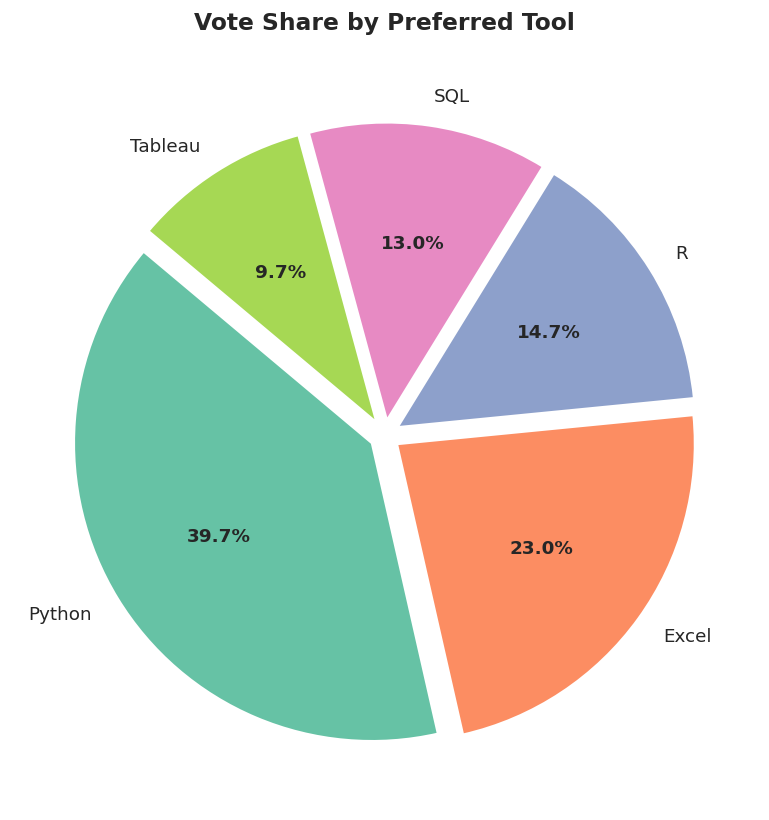

✅ Saved: chart2_pie_vote_share.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

tool_counts = df['Preferred_Tool'].value_counts()
colors      = sns.color_palette("Set2", len(tool_counts))
explode     = [0.05] * len(tool_counts)  # slight separation for all slices

wedges, texts, autotexts = ax.pie(
    tool_counts.values,
    labels      = tool_counts.index,
    autopct     = '%1.1f%%',
    colors      = colors,
    explode     = explode,
    startangle  = 140,
    wedgeprops  = dict(edgecolor='white', linewidth=1.5)
)

for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Vote Share by Preferred Tool', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart2_pie_vote_share.png')
plt.show()
print("✅ Saved: chart2_pie_vote_share.png")

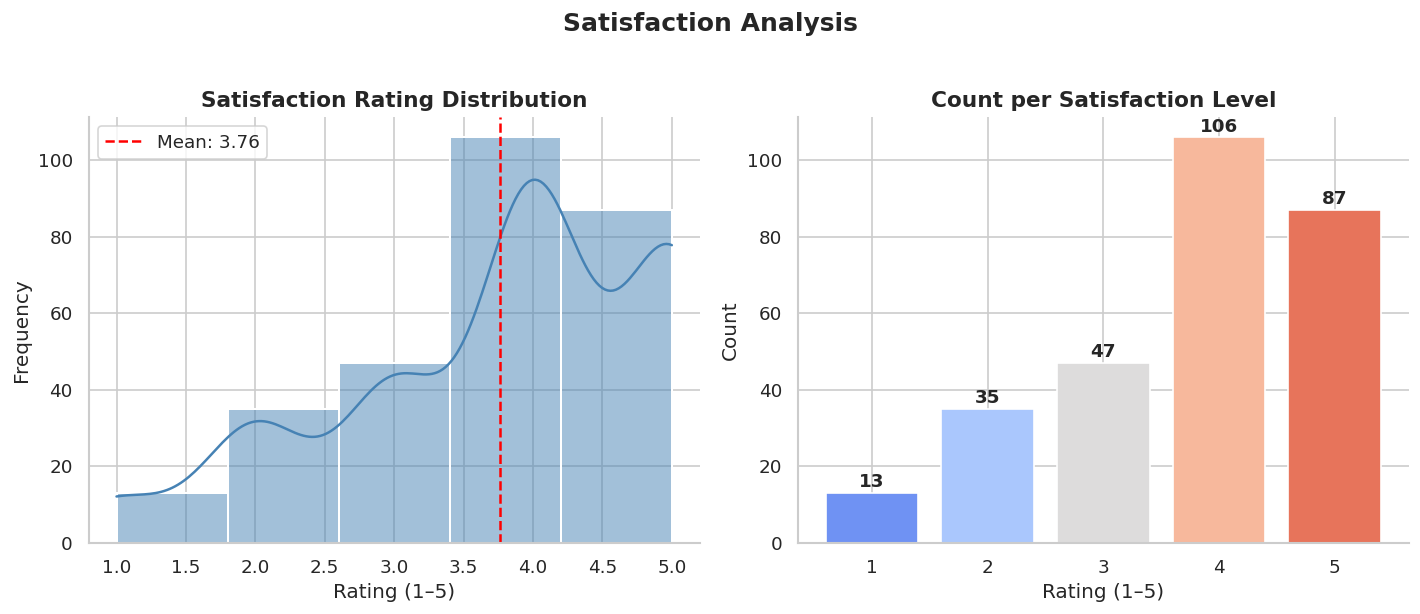

✅ Saved: chart3_satisfaction.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Histogram ---
ax1 = axes[0]
sns.histplot(df['Satisfaction'], bins=5, kde=True, color='steelblue',
             edgecolor='white', linewidth=1.2, ax=ax1)
ax1.set_title('Satisfaction Rating Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Rating (1–5)')
ax1.set_ylabel('Frequency')
ax1.axvline(df['Satisfaction'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Mean: {df['Satisfaction'].mean():.2f}")
ax1.legend()

# --- Right: Count per rating level ---
ax2 = axes[1]
rating_counts = df['Satisfaction'].value_counts().sort_index()
bars = ax2.bar(rating_counts.index, rating_counts.values,
               color=sns.color_palette("coolwarm", 5), edgecolor='white')
for bar, val in zip(bars, rating_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5, str(val),
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Count per Satisfaction Level', fontsize=13, fontweight='bold')
ax2.set_xlabel('Rating (1–5)')
ax2.set_ylabel('Count')
ax2.set_xticks([1, 2, 3, 4, 5])
sns.despine()

plt.suptitle('Satisfaction Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_satisfaction.png')
plt.show()
print("✅ Saved: chart3_satisfaction.png")

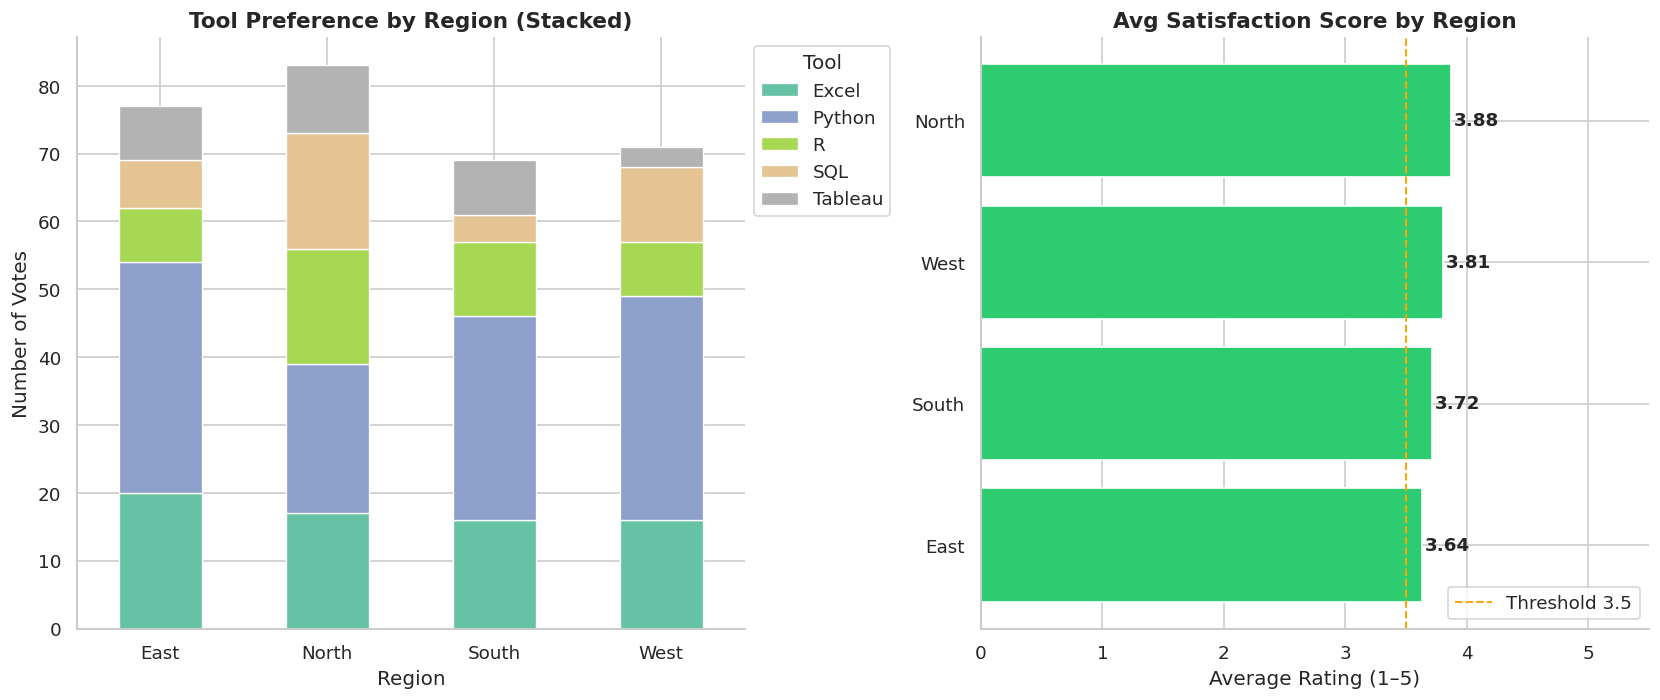

✅ Saved: chart4_region_analysis.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Region-wise vote count (stacked bar) ---
region_tool = df.groupby(['Region', 'Preferred_Tool']).size().unstack(fill_value=0)
region_tool.plot(kind='bar', stacked=True, ax=axes[0],
                 colormap='Set2', edgecolor='white', linewidth=0.8)
axes[0].set_title('Tool Preference by Region (Stacked)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Number of Votes')
axes[0].legend(title='Tool', bbox_to_anchor=(1, 1))
axes[0].tick_params(axis='x', rotation=0)
sns.despine(ax=axes[0])

# --- Right: Average satisfaction by region ---
region_sat = df.groupby('Region')['Satisfaction'].mean().sort_values(ascending=True)
colors_sat  = ['#e74c3c' if v < 3.5 else '#2ecc71' for v in region_sat.values]
bars = axes[1].barh(region_sat.index, region_sat.values, color=colors_sat, edgecolor='white')
for bar, val in zip(bars, region_sat.values):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=11, fontweight='bold')
axes[1].axvline(3.5, color='orange', linestyle='--', linewidth=1.2, label='Threshold 3.5')
axes[1].set_title('Avg Satisfaction Score by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Rating (1–5)')
axes[1].set_xlim(0, 5.5)
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('chart4_region_analysis.png')
plt.show()
print("✅ Saved: chart4_region_analysis.png")

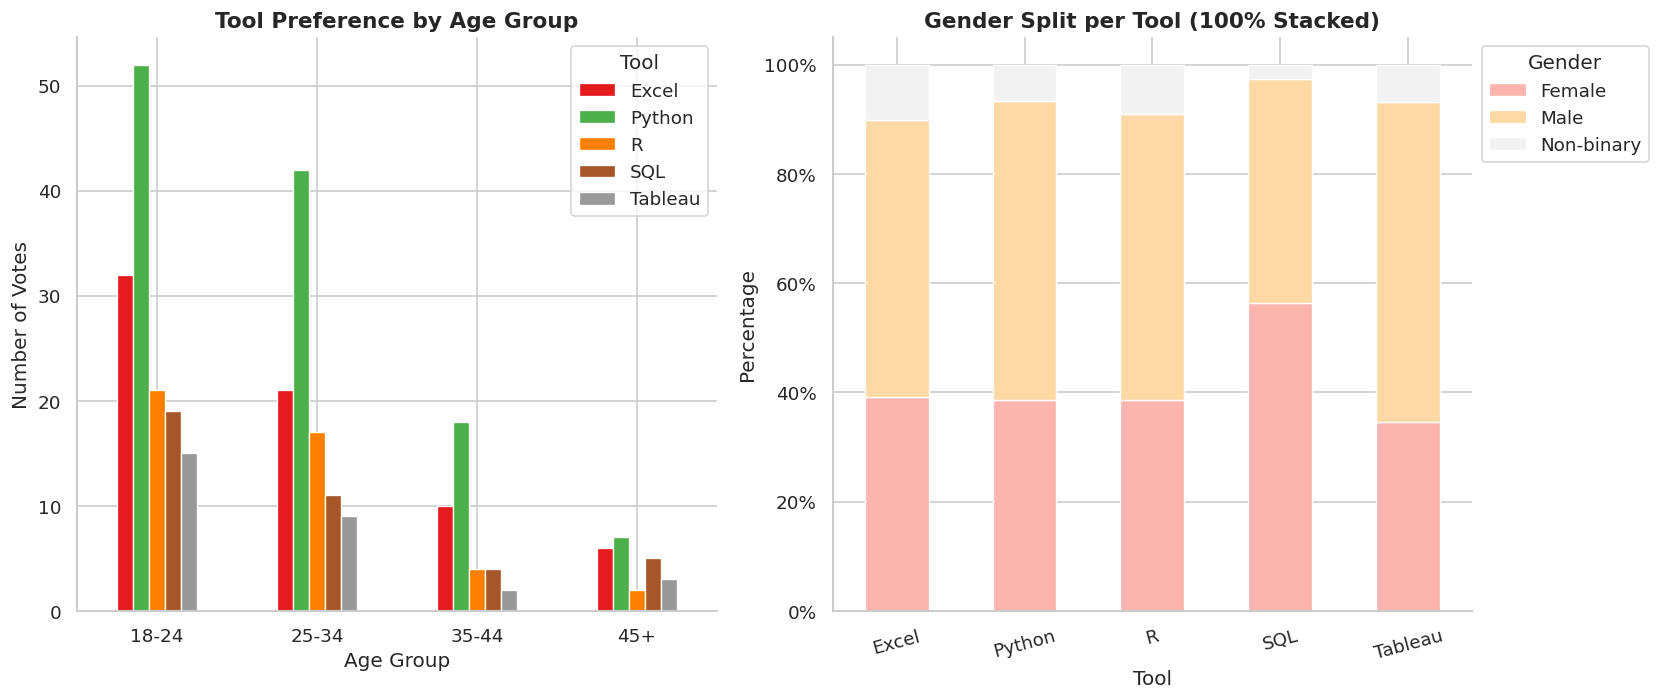

✅ Saved: chart5_demographic_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Tool preference by Age Group (grouped bar) ---
age_tool = df.groupby(['Age_Group', 'Preferred_Tool']).size().unstack(fill_value=0)
age_order = ['18-24', '25-34', '35-44', '45+']
age_tool  = age_tool.reindex(age_order)
age_tool.plot(kind='bar', ax=axes[0], colormap='Set1', edgecolor='white', linewidth=0.8)
axes[0].set_title('Tool Preference by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Votes')
axes[0].legend(title='Tool', bbox_to_anchor=(1, 1))
axes[0].tick_params(axis='x', rotation=0)
sns.despine(ax=axes[0])

# --- Right: Gender distribution per tool (100% stacked bar) ---
gender_tool = df.groupby(['Preferred_Tool', 'Gender']).size().unstack(fill_value=0)
gender_tool_pct = gender_tool.div(gender_tool.sum(axis=1), axis=0) * 100
gender_tool_pct.plot(kind='bar', stacked=True, ax=axes[1],
                     colormap='Pastel1', edgecolor='white', linewidth=0.8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Gender Split per Tool (100% Stacked)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tool')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Gender', bbox_to_anchor=(1, 1))
axes[1].tick_params(axis='x', rotation=15)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('chart5_demographic_comparison.png')
plt.show()
print("✅ Saved: chart5_demographic_comparison.png")

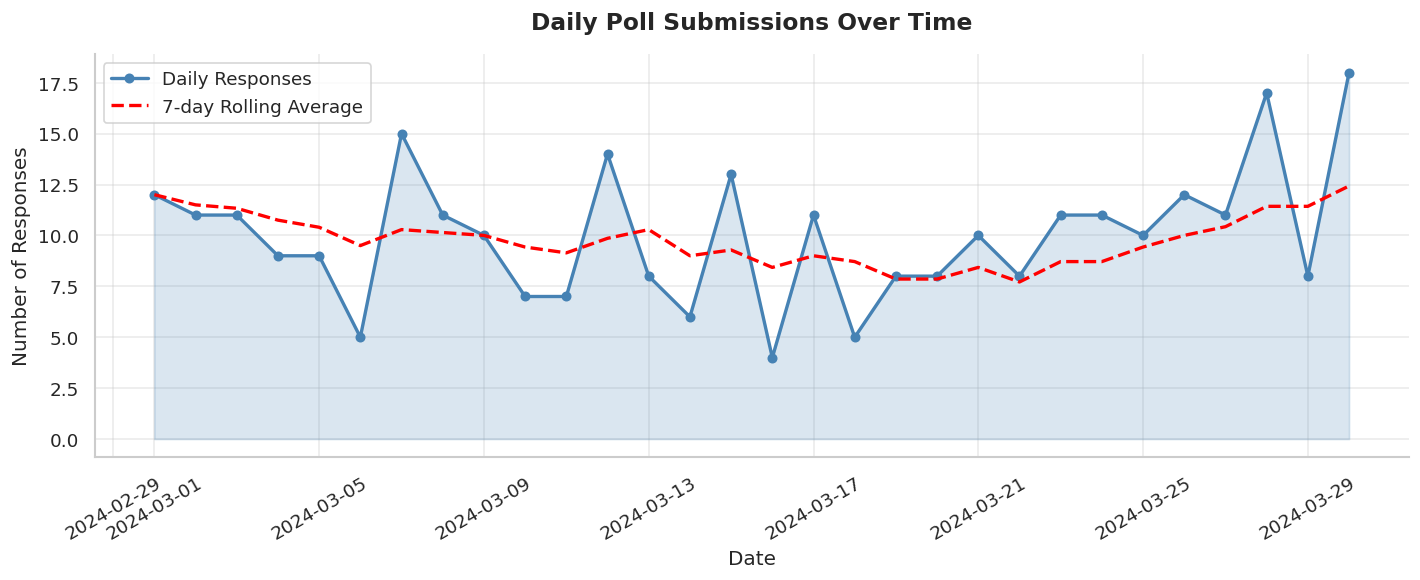

✅ Saved: chart6_daily_trend.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

daily = df.groupby(df['Timestamp'].dt.date).size().reset_index(name='Responses')
daily['Timestamp'] = pd.to_datetime(daily['Timestamp'])

ax.fill_between(daily['Timestamp'], daily['Responses'], alpha=0.2, color='steelblue')
ax.plot(daily['Timestamp'], daily['Responses'], marker='o', markersize=5,
        color='steelblue', linewidth=2, label='Daily Responses')

# 7-day rolling average
daily['Rolling_Avg'] = daily['Responses'].rolling(7, min_periods=1).mean()
ax.plot(daily['Timestamp'], daily['Rolling_Avg'], color='red', linewidth=2,
        linestyle='--', label='7-day Rolling Average')

ax.set_title('Daily Poll Submissions Over Time', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Responses')
ax.legend()
ax.grid(True, alpha=0.4)
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.savefig('chart6_daily_trend.png')
plt.show()
print("✅ Saved: chart6_daily_trend.png")

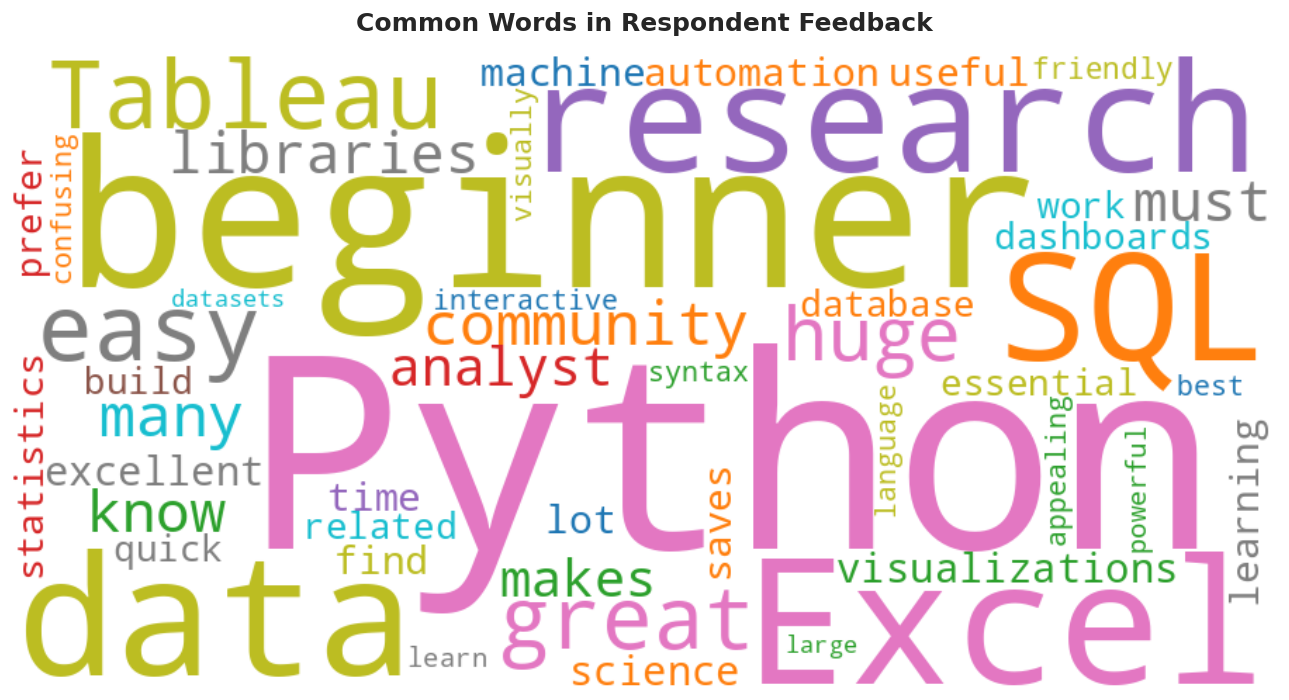

✅ Saved: chart7_wordcloud.png


In [14]:
# Filter out generic/no feedback and NaN values
cleaned_feedback = df['Feedback'].dropna()
feedback_list_for_wordcloud = cleaned_feedback[cleaned_feedback != 'No feedback provided'].tolist()
feedback_text = ' '.join(feedback_list_for_wordcloud)

wc = WordCloud(
    width            = 900,
    height           = 450,
    background_color = 'white',
    colormap         = 'tab10',
    max_words        = 80,
    collocations     = False,   # avoids repeating bigrams
    contour_width    = 1,
    contour_color    = 'steelblue'
).generate(feedback_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Respondent Feedback', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart7_wordcloud.png')
plt.show()
print("✅ Saved: chart7_wordcloud.png")

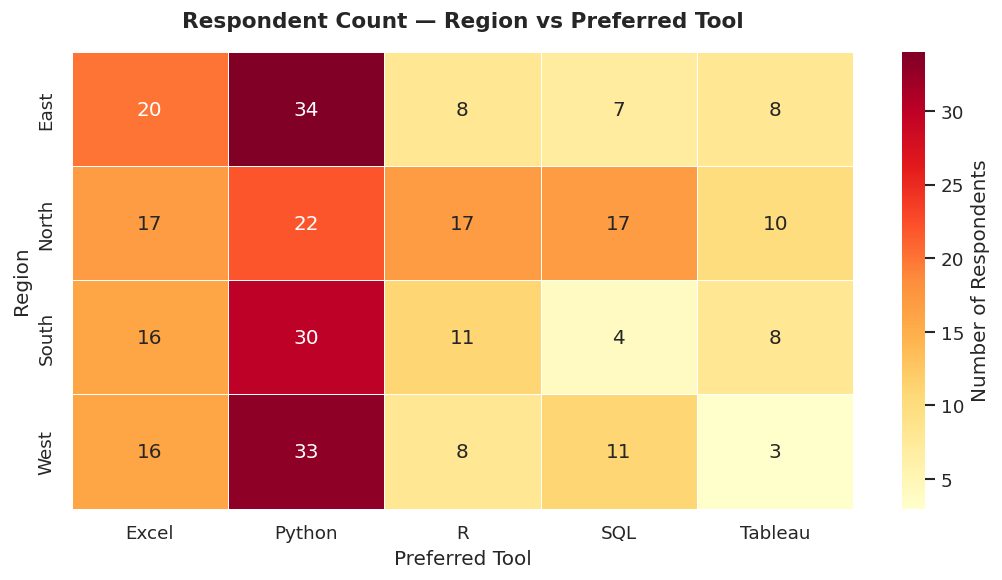

✅ Saved: chart8_heatmap.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

pivot = df.pivot_table(index='Region', columns='Preferred_Tool',
                        values='Respondent_ID', aggfunc='count', fill_value=0)

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Number of Respondents'})

ax.set_title('Respondent Count — Region vs Preferred Tool', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Preferred Tool')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig('chart8_heatmap.png')
plt.show()
print("✅ Saved: chart8_heatmap.png")

In [17]:
# -------------------------------------------------------
# WHY: In any real analyst job, you don't just send charts —
#       you write a summary of what they mean.
# -------------------------------------------------------

top_tool       = df['Preferred_Tool'].value_counts().idxmax()
top_tool_pct   = df['Preferred_Tool'].value_counts(normalize=True).max() * 100
avg_sat        = df['Satisfaction'].mean()
top_region     = df.groupby('Region')['Respondent_ID'].count().idxmax()
top_age        = df['Age_Group'].value_counts().idxmax()
top_gender     = df['Gender'].value_counts().idxmax()
high_sat_tool  = df.groupby('Preferred_Tool')['Satisfaction'].mean().idxmax()
low_sat_tool   = df.groupby('Preferred_Tool')['Satisfaction'].mean().idxmin()
peak_date      = df.groupby(df['Timestamp'].dt.date).size().idxmax()

print("=" * 60)
print("         📊 POLL RESULTS — KEY INSIGHTS REPORT")
print("=" * 60)
print(f"""
📌 SURVEY OVERVIEW
   Total Respondents    : {len(df)}
   Survey Period        : {df['Timestamp'].dt.date.min()} to {df['Timestamp'].dt.date.max()}
   Questions Covered    : Tool Preference + Satisfaction + Feedback

🏆 TOP FINDINGS
   1. Most Preferred Tool   : {top_tool} ({top_tool_pct:.1f}% of votes)
   2. Average Satisfaction  : {avg_sat:.2f} / 5.00
   3. Highest Responding    : {top_region} region
   4. Dominant Age Group    : {top_age}
   5. Most Respondents      : {top_gender}
   6. Peak Survey Day       : {peak_date}

📈 SATISFACTION INSIGHTS
   Best-rated Tool  : {high_sat_tool} (avg {df.groupby('Preferred_Tool')['Satisfaction'].mean().max():.2f}/5)
   Needs Attention  : {low_sat_tool} (avg {df.groupby('Preferred_Tool')['Satisfaction'].mean().min():.2f}/5)

✅ RECOMMENDATIONS
   → Focus training/marketing on {top_tool} since it dominates preference.
   → Improve resources around {low_sat_tool} to lift satisfaction scores.
   → The {top_region} region shows high engagement — prioritise outreach there.
   → Most respondents are aged {top_age} — design content for this group.
""")
print("=" * 60)
print("✅ Insights report generated. Copy this for your GitHub README!")

         📊 POLL RESULTS — KEY INSIGHTS REPORT

📌 SURVEY OVERVIEW
   Total Respondents    : 300
   Survey Period        : 2024-03-01 to 2024-03-30
   Questions Covered    : Tool Preference + Satisfaction + Feedback

🏆 TOP FINDINGS
   1. Most Preferred Tool   : Python (39.7% of votes)
   2. Average Satisfaction  : 3.76 / 5.00
   3. Highest Responding    : North region
   4. Dominant Age Group    : 18-24
   5. Most Respondents      : Male
   6. Peak Survey Day       : 2024-03-30

📈 SATISFACTION INSIGHTS
   Best-rated Tool  : Tableau (avg 4.00/5)
   Needs Attention  : R (avg 3.57/5)

✅ RECOMMENDATIONS
   → Focus training/marketing on Python since it dominates preference.
   → Improve resources around R to lift satisfaction scores.
   → The North region shows high engagement — prioritise outreach there.
   → Most respondents are aged 18-24 — design content for this group.

✅ Insights report generated. Copy this for your GitHub README!


In [18]:
# Download all charts and data at once from Colab
from google.colab import files
import os

# List all output files
output_files = [f for f in os.listdir('.') if f.endswith('.png') or f.endswith('.csv')]
print(f"📁 Files ready to download ({len(output_files)} files):\n")
for f in sorted(output_files):
    size = os.path.getsize(f) / 1024
    print(f"   {f:45s} ({size:.1f} KB)")

print("\n⬇️  Downloading all files now...")
for f in output_files:
    files.download(f)
print("\n✅ All files downloaded! Save them in your project's 'outputs/' and 'images/' folders.")

📁 Files ready to download (9 files):

   chart1_bar_vote_count.png                     (31.0 KB)
   chart2_pie_vote_share.png                     (53.0 KB)
   chart3_satisfaction.png                       (56.9 KB)
   chart4_region_analysis.png                    (63.3 KB)
   chart5_demographic_comparison.png             (68.9 KB)
   chart6_daily_trend.png                        (89.1 KB)
   chart7_wordcloud.png                          (352.1 KB)
   chart8_heatmap.png                            (44.3 KB)
   cleaned_poll_data.csv                         (29.7 KB)

⬇️  Downloading all files now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded! Save them in your project's 'outputs/' and 'images/' folders.


cell a


In [25]:
!pip install streamlit -q
!pip install pycloudflared -q
print("✅ Done!")

✅ Done!


In [28]:
import subprocess, threading, time, os

# Kill any old streamlit
os.system("pkill -f streamlit 2>/dev/null")
time.sleep(2)

# Start Streamlit
def run():
    subprocess.run([
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false"
    ])

threading.Thread(target=run, daemon=True).start()
print("⏳ Streamlit starting... waiting 8 seconds...")
time.sleep(8)

# Install cloudflared if not already available
if not os.path.exists('/usr/local/bin/cloudflared'):
    print("⬇️ Installing cloudflared...")
    !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
    !chmod +x cloudflared-linux-amd64
    !mv cloudflared-linux-amd64 /usr/local/bin/cloudflared
    print("✅ cloudflared installed!")

# Start cloudflare tunnel — NO SIGNUP, NO TOKEN, NO PASSWORD
print("🌐 Creating public link via Cloudflare...")
tunnel = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Wait and scan output for the public URL
import re
time.sleep(8)
output = ""
for _ in range(30):
    line = tunnel.stderr.readline().decode("utf-8")
    output += line
    match = re.search(r'https://[a-z0-9\-]+\.trycloudflare\.com', line)
    if match:
        url = match.group(0)
        print(f"\n{'='*50}")
        print(f"  🚀 YOUR DASHBOARD IS LIVE:")
        print(f"  {url}")
        print(f"{'='*50}")
        print("✅ Just click the link — no password needed!")
        break

⏳ Streamlit starting... waiting 8 seconds...
⬇️ Installing cloudflared...
✅ cloudflared installed!
🌐 Creating public link via Cloudflare...

  🚀 YOUR DASHBOARD IS LIVE:
  https://shower-nations-reading-psychiatry.trycloudflare.com
✅ Just click the link — no password needed!
